In [2]:
# !pip install torchmetrics
# !pip install hugsvision
# !pip install tensorboard

In [1]:
import torchmetrics
print(torchmetrics.__version__)

1.8.2


In [2]:
import numpy as np  # Loading data
import torch
from torch.utils.data import DataLoader, TensorDataset  # Tensor dataset and construct dataloader
import torch.optim as optim  # Optimization function
import torch.nn as nn  # Call Layers and construct model
from torch.optim.lr_scheduler import ReduceLROnPlateau  # Adjust Learning rate during training
from torchmetrics.functional import precision, recall  # PyTorch performance metrics
from torchmetrics.classification import MulticlassPrecision, MulticlassRecall, MulticlassF1Score  # Multi-class metrics
from sklearn import metrics  # Model performance metrics
import pickle
import os
import cv2  # Read image; Resize image function
from tqdm import tqdm  # Instantly make loops show progress
import matplotlib.image  # Save array as image
import shutil
from huggingface_hub import hf_hub_download  # For loading pre-trained models
from transformers import ViTImageProcessor, ViTForImageClassification  # ViTFeatureExtractor
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler  # Balancing multi-class dataset
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd

In [3]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'); print(device)

cuda


In [4]:
# Hyperparameters
batch_size = 64  # Increase if GPU memory allows
num_epochs = 30  # Keep as is, fine-tune later
learning_rate = 0.0001  # Lower LR for stable training
weight_decay = 1e-4  # Helps with generalization

In [5]:
# # Hyperparameters
# batch_size = 8
# num_epochs = 20
# learning_rate = 0.1 # Initial learning rate

# Data

In [5]:
# Load dataset
with open('C:/Users/101194208/Desktop/Die-Cast Ensemble/Data/data_oversample_usingViT.pkl', 'rb') as file:
    loaded_data = pickle.load(file)

# Access the Loaded variables
X_train, X_val, X_test = loaded_data['var1'], loaded_data['var2'], loaded_data['var3']
y_train, y_val, y_test = loaded_data['var4'], loaded_data['var5'], loaded_data['var6']

In [6]:
# Convert X to Float Tensor & y to LongTensor (required for multi-class classification)
train_dataset = TensorDataset(torch.Tensor(X_train), torch.LongTensor(y_train))
val_dataset = TensorDataset(torch.Tensor(X_val), torch.LongTensor(y_val))
test_dataset = TensorDataset(torch.Tensor(X_test), torch.LongTensor(y_test))

In [7]:
# Define DataLoader for multi-class classification
dataloader = {
    "train": DataLoader(
        dataset=train_dataset,
        batch_size=batch_size,  # Mini-batch size
        shuffle=True,  # Shuffle training data
        num_workers=0,  # Increase workers for efficiency
        drop_last=False
    ),
    "val": DataLoader(
        dataset=val_dataset,
        batch_size=batch_size,
        shuffle=False,  # No shuffle for validation
        num_workers=0,
        drop_last=False
    ),
    "test": DataLoader(
        dataset=test_dataset,
        batch_size=batch_size,
        shuffle=False,  # No shuffle for test
        num_workers=0,
        drop_last=False
    )
}

# Model Construction
3D CNN PyTorch: https://github.com/xmuyzz/3D-CNN-PyTorch/blob/master/models/cnn.py

CNN with PyTorch: https://github.com/sashrika15/CNN/tree/master

CNN with PyTorch Reference: https://pythonprogramming.net/convolutional-neural-networks-deep-learning-neural-network-pytorch/

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = self._conv_layer_set(3, 16)
        self.conv2 = self._conv_layer_set(16, 32)
        self.conv3 = self._conv_layer_set(32, 64)
        
        # Adjust the first fully connected layer size based on input dimension
        self.fc1 = nn.Linear(26 * 26 * 64, 128)  # Ensure correct input size # 60 * 60 * 64 for input image 500x500
        self.fc2 = nn.Linear(128, 3)  # Change output neurons to 3 for multi-class

        self.relu = nn.LeakyReLU()
        self.conv1_bn = nn.BatchNorm2d(16)
        self.conv2_bn = nn.BatchNorm2d(32)
        self.conv3_bn = nn.BatchNorm2d(64)
        self.fc1_bn = nn.BatchNorm1d(128)
        self.drop = nn.Dropout(p=0.3)

    def _conv_layer_set(self, in_channels, out_channels):
        conv_layer = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=(3, 3), stride=1, padding=0),
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=(2, 2), stride=2)
        )
        return conv_layer

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv1_bn(x)
        x = self.conv2(x)
        x = self.conv2_bn(x)
        x = self.conv3(x)
        x = self.conv3_bn(x)

        x = x.view(x.size(0), -1)  # Flatten before FC layer
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc1_bn(x)
        x = self.drop(x)
        x = self.fc2(x)

        return x  # Return logits (no softmax, use CrossEntropyLoss)
# Correctly do not add Softmax (since nn.CrossEntropyLoss expects raw logits).

# Model Training

Training Neural Networks with Validation using PyTorch: https://www.geeksforgeeks.org/training-neural-networks-with-validation-using-pytorch/

PyTorch CNN: https://www.youtube.com/watch?v=pDdP0TFzsoQ

Code wrapping（代码换行）: https://blog.csdn.net/u014636245/article/details/87924595

Performance metrics partly: https://vitalflux.com/accuracy-precision-recall-f1-score-python-example/

Formatted string literals (F-strings): https://www.geeksforgeeks.org/formatted-string-literals-f-strings-python/

Adjust learning rate during training: https://www.scaler.com/topics/pytorch/how-to-adjust-learning-rate-in-pytorch/

In [9]:
%%time
### Model
model = CNN().to(device)  # Update model class name if changed

criterion = nn.CrossEntropyLoss()  # Supports multi-class classification
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=5)

### Training & Validation
print('Training Model ...')

for epoch in range(num_epochs):
    print('Epoch', epoch + 1)
    
    # Training phase
    batch_loss = 0.0
    batch_acc = 0.0
    batch_precision = 0.0
    batch_recall = 0.0
    model.train()
    
    for i, (samples, labels) in enumerate(dataloader["train"]):  # Batch data
        samples = samples.to(device)  # Move data to GPU
        labels = labels.to(device).long()  # Convert labels to LongTensor
        optimizer.zero_grad()  # Clear gradients

        # Forward pass
        outputs = model(samples)  # Shape: [batch_size, num_classes]
        pred_labels = torch.argmax(outputs, dim=1)  # Get predicted class
        
        # Calculate loss
        loss = criterion(outputs, labels)
        
        # Backward and update
        loss.backward()  # Compute gradients
        optimizer.step()  # Update weights
        
        # Sum training loss and accuracy
        batch_loss += loss.item() / len(labels)
        batch_acc += torch.sum(pred_labels == labels).item() / len(labels)

        # Convert to CPU for metric calculation
        labels_cpu = labels.cpu().numpy()
        preds_cpu = pred_labels.cpu().numpy()

        # Multi-class precision & recall
        batch_precision += metrics.precision_score(labels_cpu, preds_cpu, average="macro", zero_division=0.0)
        batch_recall += metrics.recall_score(labels_cpu, preds_cpu, average="macro", zero_division=0.0)

    # Calculate training metrics
    train_loss = batch_loss / len(dataloader["train"])
    train_acc = batch_acc / len(dataloader["train"])
    train_precision = batch_precision / len(dataloader["train"])
    train_recall = batch_recall / len(dataloader["train"])

    # Validation phase
    batch_loss = 0.0
    batch_acc = 0.0
    model.eval()

    with torch.no_grad():  # Disable gradient computation for validation
        for j, (samples, labels) in enumerate(dataloader["val"]):
            samples = samples.to(device)
            labels = labels.to(device).long()

            # Forward pass only
            outputs = model(samples)
            pred_labels = torch.argmax(outputs, dim=1)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Sum validation loss and accuracy
            batch_loss += loss.item() / len(labels)
            batch_acc += torch.sum(pred_labels == labels).item() / len(labels)

    # Calculate validation loss and accuracy
    val_loss = batch_loss / len(dataloader['val'])
    val_acc = batch_acc / len(dataloader['val'])

    # Print each epoch's training and validation metrics
    nl = '\n'  # New line
    print(f'Epoch [{epoch+1}/{num_epochs}]: {nl} Train, Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f} {nl} Valid, Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f} {nl} Learning Rate: {optimizer.param_groups[0]["lr"]}')

    # Step scheduler based on train loss
    scheduler.step(train_loss)

print('Finished Training')

Training Model ...
Epoch 1
Epoch [1/30]: 
 Train, Loss: 0.0038, Accuracy: 0.9213, Precision: 0.9200, Recall: 0.9250 
 Valid, Loss: 0.0044, Accuracy: 0.9277 
 Learning Rate: 0.0001
Epoch 2
Epoch [2/30]: 
 Train, Loss: 0.0009, Accuracy: 0.9928, Precision: 0.9921, Recall: 0.9932 
 Valid, Loss: 0.0044, Accuracy: 0.9371 
 Learning Rate: 0.0001
Epoch 3
Epoch [3/30]: 
 Train, Loss: 0.0003, Accuracy: 0.9988, Precision: 0.9985, Recall: 0.9989 
 Valid, Loss: 0.0040, Accuracy: 0.9386 
 Learning Rate: 0.0001
Epoch 4
Epoch [4/30]: 
 Train, Loss: 0.0002, Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000 
 Valid, Loss: 0.0039, Accuracy: 0.9449 
 Learning Rate: 0.0001
Epoch 5
Epoch [5/30]: 
 Train, Loss: 0.0001, Accuracy: 0.9996, Precision: 0.9994, Recall: 0.9997 
 Valid, Loss: 0.0038, Accuracy: 0.9386 
 Learning Rate: 0.0001
Epoch 6
Epoch [6/30]: 
 Train, Loss: 0.0001, Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000 
 Valid, Loss: 0.0041, Accuracy: 0.9449 
 Learning Rate: 0.0001
Epoch 7
Epoch [

# Trained Model Test

In [10]:
model.eval()  # Testing mode

batch_acc = 0.0
batch_precision = 0.0
batch_recall = 0.0
prob_all = []
true_labels = []
pred_all = []

for k, (samples, labels) in enumerate(dataloader["test"]):
    samples = samples.to(device)  # Move data to GPU
    labels = labels.to(device).long()  # Ensure labels are LongTensor

    # Forward pass
    outputs = model(samples)
    softmax_outputs = nn.functional.softmax(outputs, dim=1)  # Get class probabilities
    
    # Get predicted class
    pred_labels = torch.argmax(softmax_outputs, dim=1)

    # Store probabilities and labels
    prob_all.extend(softmax_outputs.cpu().detach().numpy())  # Store entire probability vector
    true_labels.extend(labels.cpu().detach().numpy())
    pred_all.extend(pred_labels.cpu().detach().numpy())

    # Sum batch Accuracy
    batch_acc += torch.sum(pred_labels == labels).item() / len(labels)

    # Convert to CPU for metric calculation
    labels_cpu = labels.cpu().numpy()
    preds_cpu = pred_labels.cpu().numpy()

    # Multi-class precision & recall
    batch_precision += metrics.precision_score(labels_cpu, preds_cpu, average="macro", zero_division=0.0)
    batch_recall += metrics.recall_score(labels_cpu, preds_cpu, average="macro", zero_division=0.0)

# Calculate final testing performance metrics
acc = batch_acc / len(dataloader["test"])
precision = batch_precision / len(dataloader["test"])
recall = batch_recall / len(dataloader["test"])

# Print testing performance metrics
nl = '\n'  # New line
print(f'Testing: {nl} Accuracy = {acc:.4f} {nl} Precision = {precision:.4f} {nl} Recall = {recall:.4f}')


Testing: 
 Accuracy = 0.9542 
 Precision = 0.6907 
 Recall = 0.6680


# ROC Curve Plot
https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html

In [22]:
from sklearn.preprocessing import LabelBinarizer

label_binarizer = LabelBinarizer().fit(y_train)
y_onehot_test = label_binarizer.transform(y_test)
print(y_onehot_test.shape)  # (n_samples, n_classes)

n_classes = 3

(334, 3)


In [12]:
from sklearn.metrics import auc, roc_curve

# store the fpr, tpr, and roc_auc for all averaging strategies
fpr, tpr, roc_auc = dict(), dict(), dict()
# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_onehot_test.ravel(), np.array(prob_all).ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

print(f"Micro-averaged One-vs-Rest ROC AUC score:\n{roc_auc['micro']:.2f}")

# Compute macro-average ROC curve and ROC area
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_onehot_test[:, i], np.array(prob_all)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr_grid = np.linspace(0.0, 1.0, 1000)

# Interpolate all ROC curves at these points
mean_tpr = np.zeros_like(fpr_grid)

for i in range(n_classes):
    mean_tpr += np.interp(fpr_grid, fpr[i], tpr[i])  # linear interpolation

# Average it and compute AUC
mean_tpr /= n_classes

fpr["macro"] = fpr_grid
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

print(f"Macro-averaged One-vs-Rest ROC AUC score:\n{roc_auc['macro']:.2f}")
# #This computation is equivalent to simply calling
# macro_roc_auc_ovr = roc_auc_score(
#     y_test,
#     y_score,
#     multi_class="ovr",
#     average="macro",
# )

# print(f"Macro-averaged One-vs-Rest ROC AUC score:\n{macro_roc_auc_ovr:.2f}")

Micro-averaged One-vs-Rest ROC AUC score:
0.99
Macro-averaged One-vs-Rest ROC AUC score:
0.99


In [13]:
fpr

{'micro': array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.00149701, 0.00149701, 0.00299401, 0.00299401, 0.00449102,
        0.00449102, 0.00598802, 0.00598802, 0.00748503, 0.00748503,
        0.00898204, 0.00898204, 0.01047904, 0.01047904, 0.01796407,
        0.01796407, 0.02095808, 0.02095808, 0.02245509, 0.02245509,
        0.0254491 , 0.0254491 , 0.0494012 , 0.0494012 , 0.06886228,
        0.06886228, 0.07335329, 0.07335329, 0.10628743, 0.10628743,
        0.1497006 , 0.1497006 , 0.2754491 , 0.2754491 , 0.4505988 ,
        0.4505988 , 1.        ]),
 0: array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
  

In [15]:
target_names = ['Flawless', 'Crack', 'Cold Flow']

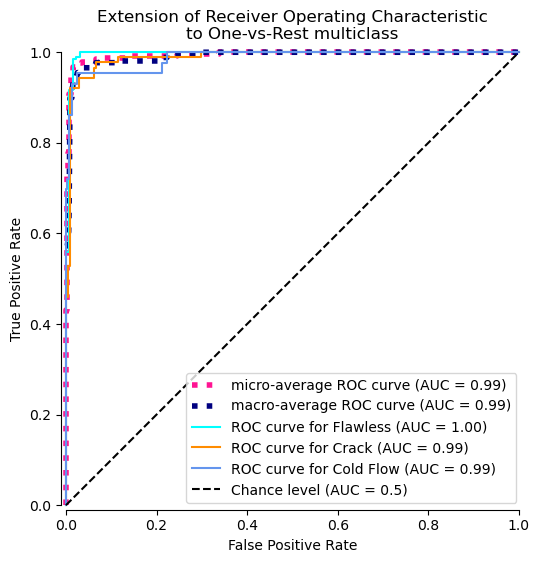

In [16]:
from itertools import cycle
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(6, 6))

plt.plot(
    fpr["micro"],
    tpr["micro"],
    label=f"micro-average ROC curve (AUC = {roc_auc['micro']:.2f})",
    color="deeppink",
    linestyle=":",
    linewidth=4,
)

plt.plot(
    fpr["macro"],
    tpr["macro"],
    label=f"macro-average ROC curve (AUC = {roc_auc['macro']:.2f})",
    color="navy",
    linestyle=":",
    linewidth=4,
)

colors = cycle(["aqua", "darkorange", "cornflowerblue"])
for class_id, color in zip(range(n_classes), colors):
    RocCurveDisplay.from_predictions(
        y_onehot_test[:, class_id],
        np.array(prob_all)[:, class_id],
        name=f"ROC curve for {target_names[class_id]}",
        color=color,
        ax=ax,
        plot_chance_level=(class_id == 2),
        despine=True,
    )

_ = ax.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="Extension of Receiver Operating Characteristic\nto One-vs-Rest multiclass",
)

# Replicate Running

In [13]:
%%time
times = 10 # number of running times
all_runs = []
for i in range(times):
    # Training & Validation
    model = CNN().to(device)  # Update model class name if changed
    criterion = nn.CrossEntropyLoss()  # Supports multi-class classification
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=5)
    print('Training Model ...')
    for epoch in range(num_epochs):
        print('Epoch', epoch + 1)
        # Training phase
        batch_loss = 0.0
        batch_acc = 0.0
        batch_precision = 0.0
        batch_recall = 0.0
        model.train()
        for i, (samples, labels) in enumerate(dataloader["train"]):  # Batch data
            samples = samples.to(device)  # Move data to GPU
            labels = labels.to(device).long()  # Convert labels to LongTensor
            optimizer.zero_grad()  # Clear gradients
            # Forward pass
            outputs = model(samples)  # Shape: [batch_size, num_classes]
            pred_labels = torch.argmax(outputs, dim=1)  # Get predicted class
            # Calculate loss
            loss = criterion(outputs, labels)
            # Backward and update
            loss.backward()  # Compute gradients
            optimizer.step()  # Update weights
            # Sum training loss and accuracy
            batch_loss += loss.item() / len(labels)
            batch_acc += torch.sum(pred_labels == labels).item() / len(labels)
            # Convert to CPU for metric calculation
            labels_cpu = labels.cpu().numpy()
            preds_cpu = pred_labels.cpu().numpy()
            # Multi-class precision & recall
            batch_precision += metrics.precision_score(labels_cpu, preds_cpu, average="macro", zero_division=0.0)
            batch_recall += metrics.recall_score(labels_cpu, preds_cpu, average="macro", zero_division=0.0)
        # Calculate training metrics
        train_loss = batch_loss / len(dataloader["train"])
        train_acc = batch_acc / len(dataloader["train"])
        train_precision = batch_precision / len(dataloader["train"])
        train_recall = batch_recall / len(dataloader["train"])
        # Validation phase
        batch_loss = 0.0
        batch_acc = 0.0
        model.eval()
        with torch.no_grad():  # Disable gradient computation for validation
            for j, (samples, labels) in enumerate(dataloader["val"]):
                samples = samples.to(device)
                labels = labels.to(device).long()
                # Forward pass only
                outputs = model(samples)
                pred_labels = torch.argmax(outputs, dim=1)
                # Calculate loss
                loss = criterion(outputs, labels)
                # Sum validation loss and accuracy
                batch_loss += loss.item() / len(labels)
                batch_acc += torch.sum(pred_labels == labels).item() / len(labels)
        # Calculate validation loss and accuracy
        val_loss = batch_loss / len(dataloader['val'])
        val_acc = batch_acc / len(dataloader['val'])
        # Print each epoch's training and validation metrics
        nl = '\n'  # New line
        print(f'Epoch [{epoch+1}/{num_epochs}]: {nl} Train, Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f} {nl} Valid, Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f} {nl} Learning Rate: {optimizer.param_groups[0]["lr"]}')
        # Step scheduler based on train loss
        scheduler.step(train_loss)
    print('Finished Training')

    # Testing
    model.eval()
    batch_acc = 0.0
    batch_precision = 0.0
    batch_recall = 0.0
    prob_all = []
    true_labels = []
    pred_all = []
    for k, (samples, labels) in enumerate(dataloader["test"]):
        samples = samples.to(device)  # Move data to GPU
        labels = labels.to(device).long()  # Ensure labels are LongTensor
        # Forward pass
        outputs = model(samples)
        softmax_outputs = nn.functional.softmax(outputs, dim=1)  # Get class probabilities
        # Get predicted class
        pred_labels = torch.argmax(softmax_outputs, dim=1)
        # Store probabilities and labels
        prob_all.extend(softmax_outputs.cpu().detach().numpy())  # Store entire probability vector
        true_labels.extend(labels.cpu().detach().numpy())
        pred_all.extend(pred_labels.cpu().detach().numpy())
        # Sum batch Accuracy
        batch_acc += torch.sum(pred_labels == labels).item() / len(labels)
        # Convert to CPU for metric calculation
        labels_cpu = labels.cpu().numpy()
        preds_cpu = pred_labels.cpu().numpy()
        # Multi-class precision & recall
        batch_precision += metrics.precision_score(labels_cpu, preds_cpu, average="macro", zero_division=0.0)
        batch_recall += metrics.recall_score(labels_cpu, preds_cpu, average="macro", zero_division=0.0)
    # Calculate final testing performance metrics
    acc = batch_acc / len(dataloader["test"])
    precision = batch_precision / len(dataloader["test"])
    recall = batch_recall / len(dataloader["test"])
    # Print testing performance metrics
    nl = '\n'  # New line
    print(f'Testing: {nl} Accuracy = {acc:.4f} {nl} Precision = {precision:.4f} {nl} Recall = {recall:.4f}')

    # Save prob_all of all runs
    prob_all_2d = np.vstack(prob_all)         # or np.array(prob_all)
    all_runs.append(prob_all_2d)

# Now stack to shape (n_runs, n_samples, n_classes)
all_runs_array = np.stack(all_runs, axis=0)   # raises if shapes differ
# Example:
# all_runs_array.shape -> (10, n_samples, n_classes)
# all_runs_array[2] -> run index 2, shape (n_samples, n_classes)
# all_runs_array[:, :, 1] -> class-1 probabilities across runs & samples

Training Model ...
Epoch 1
Epoch [1/30]: 
 Train, Loss: 0.0035, Accuracy: 0.9257, Precision: 0.9246, Recall: 0.9277 
 Valid, Loss: 0.0037, Accuracy: 0.9246 
 Learning Rate: 0.0001
Epoch 2
Epoch [2/30]: 
 Train, Loss: 0.0008, Accuracy: 0.9897, Precision: 0.9891, Recall: 0.9905 
 Valid, Loss: 0.0034, Accuracy: 0.9355 
 Learning Rate: 0.0001
Epoch 3
Epoch [3/30]: 
 Train, Loss: 0.0003, Accuracy: 0.9992, Precision: 0.9991, Recall: 0.9993 
 Valid, Loss: 0.0040, Accuracy: 0.9511 
 Learning Rate: 0.0001
Epoch 4
Epoch [4/30]: 
 Train, Loss: 0.0002, Accuracy: 0.9994, Precision: 0.9993, Recall: 0.9994 
 Valid, Loss: 0.0041, Accuracy: 0.9558 
 Learning Rate: 0.0001
Epoch 5
Epoch [5/30]: 
 Train, Loss: 0.0001, Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000 
 Valid, Loss: 0.0037, Accuracy: 0.9574 
 Learning Rate: 0.0001
Epoch 6
Epoch [6/30]: 
 Train, Loss: 0.0001, Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000 
 Valid, Loss: 0.0037, Accuracy: 0.9558 
 Learning Rate: 0.0001
Epoch 7
Epoch [

In [14]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import auc, roc_curve

label_binarizer = LabelBinarizer().fit(y_train)
y_onehot_test = label_binarizer.transform(y_test)
n_classes = 3

all_auc = []
all_fpr = []
all_tpr = []
for i in range(times):
    prob_all = all_runs_array[i]
    fpr, tpr, roc_auc = dict(), dict(), dict()
    fpr["micro"], tpr["micro"], _ = roc_curve(y_onehot_test.ravel(), np.array(prob_all).ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_onehot_test[:, i], np.array(prob_all)[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    fpr_grid = np.linspace(0.0, 1.0, 1000)
    mean_tpr = np.zeros_like(fpr_grid)
    for i in range(n_classes):
        mean_tpr += np.interp(fpr_grid, fpr[i], tpr[i])  # linear interpolation
    mean_tpr /= n_classes
    fpr["macro"] = fpr_grid
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    all_auc.append(roc_auc)
    all_fpr.append(fpr)
    all_tpr.append(tpr)

In [15]:
all_auc

[{'micro': np.float64(0.9930393703610743),
  0: np.float64(0.9938493849384938),
  1: np.float64(0.9877092409997706),
  2: np.float64(0.9874530488292176),
  'macro': np.float64(0.9896311255532819)},
 {'micro': np.float64(0.9893730503065725),
  0: np.float64(0.9966996699669968),
  1: np.float64(0.9884430176565008),
  2: np.float64(0.9573243826420523),
  'macro': np.float64(0.9807391221069954)},
 {'micro': np.float64(0.9959302950984259),
  0: np.float64(0.9983873387338734),
  1: np.float64(0.9925246503095619),
  2: np.float64(0.9918484775833133),
  'macro': np.float64(0.9942271850379175)},
 {'micro': np.float64(0.992337928932554),
  0: np.float64(0.9984998499849985),
  1: np.float64(0.9901857372162348),
  2: np.float64(0.9735475105889875),
  'macro': np.float64(0.9872956794836334)},
 {'micro': np.float64(0.991138979525978),
  0: np.float64(0.9925367536753675),
  1: np.float64(0.9839027745929833),
  2: np.float64(0.9842563733716934),
  'macro': np.float64(0.9868524185152345)},
 {'micro': n

In [16]:
all_tpr

[{'micro': array([0.        , 0.00299401, 0.05389222, 0.05988024, 0.14670659,
         0.15568862, 0.16467066, 0.17065868, 0.19760479, 0.20658683,
         0.21257485, 0.25748503, 0.25748503, 0.2994012 , 0.30538922,
         0.36526946, 0.37125749, 0.3742515 , 0.38023952, 0.38922156,
         0.40718563, 0.41317365, 0.45808383, 0.46407186, 0.48502994,
         0.49101796, 0.50598802, 0.51197605, 0.55988024, 0.56586826,
         0.58083832, 0.58682635, 0.59580838, 0.60179641, 0.75748503,
         0.75748503, 0.78443114, 0.78443114, 0.86826347, 0.86826347,
         0.8742515 , 0.8742515 , 0.90419162, 0.90419162, 0.92814371,
         0.92814371, 0.94011976, 0.94011976, 0.95209581, 0.95209581,
         0.96407186, 0.96407186, 0.96706587, 0.96706587, 0.97305389,
         0.97305389, 0.9760479 , 0.9760479 , 0.97904192, 0.97904192,
         0.98203593, 0.98203593, 0.98502994, 0.98502994, 0.98802395,
         0.98802395, 0.99101796, 0.99101796, 0.99401198, 0.99401198,
         0.99700599, 0.99

In [18]:
y_onehot_test

array([[0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       ...,
       [0, 0, 1],
       [0, 0, 1],
       [0, 0, 1]])

In [17]:
# with open('C:/Users/101194208/Desktop/Die-Cast Ensemble/Data/auc_cnn.pkl', 'wb') as f:
#         pickle.dump(all_auc, f)

# Save the dataset using pickle
dt = {
    'var1': all_runs_array,
    'var2': all_auc,
    'var3': all_fpr,
    'var4': all_tpr
}

# Save to file
with open('C:/Users/101194208/Desktop/Die-Cast Ensemble/Data/cnn.pkl', 'wb') as file:
    pickle.dump(dt, file)

In [19]:
with open('C:/Users/101194208/Desktop/Die-Cast Ensemble/Data/y_onehot_test.pkl', 'wb') as f:
        pickle.dump(y_onehot_test, f)

# Old

In [15]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve
import pandas as pd

# Binarize labels for multi-class classification
num_classes = len(set(true_labels))  # Get number of unique classes
true_labels_bin = label_binarize(true_labels, classes=list(range(num_classes)))

# Compute ROC curve for each class
fpr = {}
tpr = {}
roc_data = []

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(true_labels_bin[:, i], np.array(prob_all)[:, i])
    roc_data.append(pd.DataFrame({'fpr': fpr[i], 'tpr': tpr[i], 'class': i}))

# Combine all class ROC data
df_fpr_tpr = pd.concat(roc_data, ignore_index=True)

# Save to CSV
df_fpr_tpr.to_csv('C:/Users/101194208/Desktop/die_casting_ensemble/Result/fpr_tpr_cnn_multiclass.csv', index=False)

In [21]:
true_labels

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [22]:
pred_all

[1,
 2,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [27]:
import csv
with open('C:/Users/101194208/Desktop/die_casting_ensemble/Result/true_pred_cnn.csv', 'w', newline='') as csvfile:
    csv_writer = csv.writer(csvfile)
    for item1, item2 in zip(true_labels, pred_all):
        csv_writer.writerow([item1, item2])

In [16]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve
import pandas as pd

# Binarize labels for multi-class classification
num_classes = len(set(true_labels))  # Get number of unique classes
true_labels_bin = label_binarize(true_labels, classes=list(range(num_classes)))

# Compute Precision-Recall curve for each class
precision = {}
recall = {}
pr_data = []

for i in range(num_classes):
    precision[i], recall[i], _ = precision_recall_curve(true_labels_bin[:, i], np.array(prob_all)[:, i])
    pr_data.append(pd.DataFrame({'precision': precision[i], 'recall': recall[i], 'class': i}))

# Combine all class PR data
df_pr = pd.concat(pr_data, ignore_index=True)

# Save to CSV
df_pr.to_csv('C:/Users/101160998/Desktop/Research1/Dataset/pr_cnn_multiclass.csv', index=False)


# Check Model Structure

In [1]:
import numpy as np  # Loading data
import torch
from torch.utils.data import DataLoader, TensorDataset  # Tensor dataset and construct dataloader
import torch.optim as optim  # Optimization function
import torch.nn as nn  # Call Layers and construct model
from torch.optim.lr_scheduler import ReduceLROnPlateau  # Adjust learning rate during training
from torchmetrics.functional import precision, recall  # PyTorch performance metrics
from torchmetrics.classification import MulticlassPrecision, MulticlassRecall, MulticlassF1Score
from sklearn import metrics  # Model performance metrics
import pickle
import os
import cv2  # Read image; Resize image function
from tqdm import tqdm  # Instantly make your loops show a smart progress meter - just wrap any iterable with tqdm(iterable)
import matplotlib.image  # Save array as image
import shutil
from hugsvision.dataio.VisionDataset import VisionDataset
from hugsvision.nnet.VisionClassifierTrainer import VisionClassifierTrainer
import os.path
from transformers import ViTImageProcessor, ViTForImageClassification  # ViTFeatureExtractor
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler


In [2]:
import torch
import torch.nn as nn

class cnn(nn.Module):
    def __init__(self, num_classes=3):  # Modify this for the correct number of classes
        super(cnn, self).__init__()
        self.conv1 = self._conv_layer_set(3, 16)
        self.conv2 = self._conv_layer_set(16, 32)
        self.conv3 = self._conv_layer_set(32, 64)

        self.fc1 = nn.Linear(60 * 60 * 64, 128)  # Adjust if input image size changes
        self.fc2 = nn.Linear(128, num_classes)   # Changed from 2 to num_classes

        self.relu = nn.LeakyReLU()
        self.conv1_bn = nn.BatchNorm2d(16)
        self.conv2_bn = nn.BatchNorm2d(32)
        self.conv3_bn = nn.BatchNorm2d(64)
        self.fc1_bn = nn.BatchNorm1d(128)
        self.drop = nn.Dropout(p=0.3)

    def _conv_layer_set(self, in_channels, out_channels):
        conv_layer = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=0),
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        return conv_layer

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv1_bn(x)
        x = self.conv2(x)
        x = self.conv2_bn(x)
        x = self.conv3(x)
        x = self.conv3_bn(x)

        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc1_bn(x)
        x = self.drop(x)
        x = self.fc2(x)  # No softmax here (CrossEntropyLoss applies it internally)

        return x  # Return raw logits


In [5]:
import torch.nn as nn

def _conv_layer_set(in_channels, out_channels):
    conv_layer = nn.Sequential(
        nn.Conv2d(
            in_channels, 
            out_channels, 
            kernel_size=(3, 3), 
            stride=1, 
            padding=0
        ),
        nn.LeakyReLU(),
        nn.MaxPool2d(kernel_size=(2, 2), stride=2)
    )
    return conv_layer

# Set the number of classes dynamically
num_classes = 3  # Modify this based on your dataset

conv1 = _conv_layer_set(3, 16)
conv2 = _conv_layer_set(16, 32)
conv3 = _conv_layer_set(32, 64)

fc1 = nn.Linear(26 * 26 * 64, 128)  # Ensure the input size matches
fc2 = nn.Linear(128, num_classes)   # Modified for multi-class classification

relu = nn.LeakyReLU()
conv1_bn = nn.BatchNorm2d(16)
conv2_bn = nn.BatchNorm2d(32)
conv3_bn = nn.BatchNorm2d(64)
fc1_bn = nn.BatchNorm1d(128)
drop = nn.Dropout(p=0.3)

# Remove Softmax inside the model, as CrossEntropyLoss will handle it


In [6]:
import torch

# Define number of classes
num_classes = 3  # Modify this based on your dataset

x = torch.randn(16, 3, 224, 224)  # 16 batch size, 3 channels, 224x224 image
print(x.shape)

x = conv1(x); print(x.shape)
x = conv1_bn(x); print(x.shape)
x = conv2(x); print(x.shape)
x = conv2_bn(x); print(x.shape)
x = conv3(x); print(x.shape)
x = conv3_bn(x); print(x.shape)

# Flatten for FC layers
x = x.view(x.size(0), -1)
print(x.shape)  # Expected: [16, Flattened size]

x = fc1(x); print(x.shape)  
x = relu(x); print(x.shape)  
x = fc1_bn(x); print(x.shape)  
x = drop(x); print(x.shape)  

# Updated Fully Connected Layer for Multi-Class
fc2 = nn.Linear(128, num_classes)  # Change output size dynamically
x = fc2(x); print(x.shape)  # Expected: [16, num_classes]


torch.Size([16, 3, 224, 224])
torch.Size([16, 16, 111, 111])
torch.Size([16, 16, 111, 111])
torch.Size([16, 32, 54, 54])
torch.Size([16, 32, 54, 54])
torch.Size([16, 64, 26, 26])
torch.Size([16, 64, 26, 26])
torch.Size([16, 43264])
torch.Size([16, 128])
torch.Size([16, 128])
torch.Size([16, 128])
torch.Size([16, 128])
torch.Size([16, 3])


In [21]:
#!pip install seaborn

In [22]:
import torch
import numpy as np

# Set model to evaluation mode
model.eval()

# Store probabilities and true labels
probabilities = []
true_labels_list = []

# Loop through test data
with torch.no_grad():  # Disable gradient computation for inference
    for samples, labels in dataloader["test"]:
        samples = samples.to(device)  # Move to GPU if available
        labels = labels.to(device)  # Move labels to device
        
        outputs = model(samples)  # Get model predictions (logits)
        probs = torch.nn.functional.softmax(outputs, dim=1)  # Apply softmax to get probabilities
        
        probabilities.append(probs.cpu().numpy())  # Move to CPU and convert to NumPy
        true_labels_list.append(labels.cpu().numpy())  # Store true labels

# Convert lists to NumPy arrays
probabilities = np.concatenate(probabilities, axis=0)  # Shape: (num_samples, num_classes)
true_labels = np.concatenate(true_labels_list, axis=0)  # Shape: (num_samples,)

# Print shape to verify
print("Probabilities shape:", probabilities.shape)
print("True labels shape:", true_labels.shape)


Probabilities shape: (334, 3)
True labels shape: (334,)


In [23]:
%matplotlib inline  

In [24]:
import matplotlib.pyplot as plt

In [25]:
# plt.switch_backend('agg')  # Use this if running in a script (optional)

In [29]:
import numpy as np

true_labels = np.array(true_labels)  # Convert to NumPy array if needed
pred_labels = np.array(pred_labels)  # Convert predictions as well

In [30]:
print(type(true_labels), type(pred_labels))  # Should be list or numpy array
print(true_labels.shape, pred_labels.shape)  # Should be 1D: (num_samples,)

<class 'numpy.ndarray'> <class 'numpy.ndarray'>
(10,) (10,)


In [31]:
true_labels = np.array(true_labels).flatten()  # Ensure it's 1D
pred_labels = np.array(pred_labels).flatten()  # Ensure it's 1D

print(true_labels.shape, pred_labels.shape)  # Should now be (num_samples,)

(10,) (10,)


In [32]:
print(type(true_labels), type(pred_labels))  # Should be numpy arrays or lists
print(true_labels.shape, pred_labels.shape)  # Should be (num_samples,)
print(true_labels[:10])  # Print first 10 elements
print(pred_labels[:10])  # Check values

<class 'numpy.ndarray'> <class 'numpy.ndarray'>
(10,) (10,)
[0 1 2 1 0 2 2 1 0 1]
[0 2 2 1 0 2 1 1 0 2]


In [33]:
true_labels = np.array(true_labels).flatten()
pred_labels = np.array(pred_labels).flatten()

In [34]:
print("Unique True Labels:", np.unique(true_labels))
print("Unique Pred Labels:", np.unique(pred_labels))

Unique True Labels: [0 1 2]
Unique Pred Labels: [0 1 2]


In [35]:
from sklearn.metrics import f1_score

f1 = f1_score(true_labels, pred_labels, average='weighted')  # Weighted F1-score
print(f"Weighted F1-Score: {f1:.4f}")

Weighted F1-Score: 0.7000


In [36]:
print(type(true_labels), type(pred_labels))  # Should be numpy.ndarray
print(true_labels.shape, pred_labels.shape)  # Should be 1D (num_samples,)
print("Unique True Labels:", np.unique(true_labels))
print("Unique Pred Labels:", np.unique(pred_labels))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>
(10,) (10,)
Unique True Labels: [0 1 2]
Unique Pred Labels: [0 1 2]


In [37]:
f1_per_class = f1_score(true_labels, pred_labels, average=None)
print("F1-Score per class:", f1_per_class)

F1-Score per class: [1.         0.57142857 0.57142857]


In [38]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(true_labels, pred_labels, average='weighted')
recall = recall_score(true_labels, pred_labels, average='weighted')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Precision: 0.7167
Recall: 0.7000


In [39]:
import torch
import numpy as np

# Set model to evaluation mode
model.eval()

# Store probabilities and true labels
probabilities = []
true_labels_list = []

# Loop through test data
with torch.no_grad():  # Disable gradient computation for inference
    for samples, labels in dataloader["test"]:
        samples = samples.to(device)  # Move to GPU if available
        labels = labels.to(device)  # Move labels to device
        
        outputs = model(samples)  # Get model predictions (logits)
        probs = torch.nn.functional.softmax(outputs, dim=1)  # Apply softmax to get probabilities
        
        probabilities.append(probs.cpu().numpy())  # Move to CPU and convert to NumPy
        true_labels_list.append(labels.cpu().numpy())  # Store true labels

# Convert lists to NumPy arrays
probabilities = np.concatenate(probabilities, axis=0)  # Shape: (num_samples, num_classes)
true_labels = np.concatenate(true_labels_list, axis=0)  # Shape: (num_samples,)

# Print shape to verify
print("Probabilities shape:", probabilities.shape)
print("True labels shape:", true_labels.shape)


Probabilities shape: (334, 3)
True labels shape: (334,)


In [40]:
# %matplotlib inline
# import matplotlib
# matplotlib.use('TkAgg')  # Switch backend (or try 'Qt5Agg', 'Agg', 'module://matplotlib_inline.backend_inline')
# import matplotlib.pyplot as plt

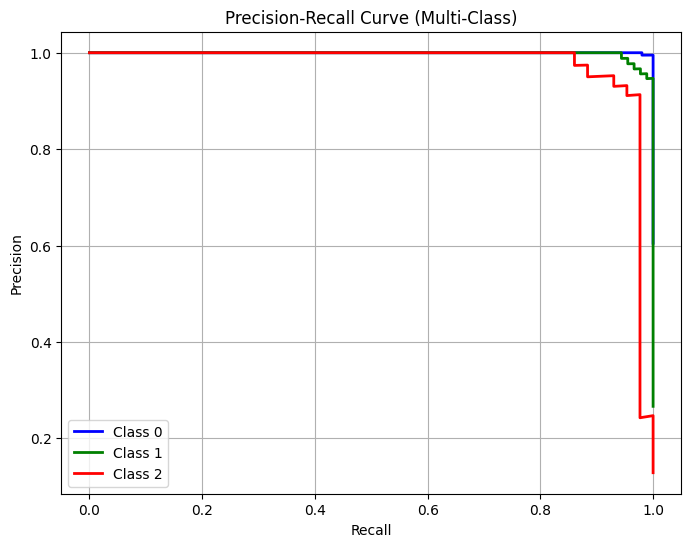

In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from itertools import cycle

# Define colors for each class
colors = cycle(["b", "g", "r"])

# Number of classes
num_classes = probabilities.shape[1]

# Plot Precision-Recall curve for each class
plt.figure(figsize=(8, 6))
for i, color in zip(range(num_classes), colors):
    precision, recall, _ = precision_recall_curve(true_labels == i, probabilities[:, i])
    plt.plot(recall, precision, color=color, lw=2, label=f'Class {i}')

# Plot details
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Multi-Class)")
plt.legend(loc="best")
plt.grid()
plt.show()

In [42]:
import numpy as np
import torch

# Set custom threshold (default is 0.5, adjust as needed)
custom_threshold = 0.6  # Example: Increase to favor precision over recall

# Get model predictions (probabilities)
model.eval()
probabilities = []  # Store predicted probabilities
true_labels_list = []  # Store true labels

with torch.no_grad():
    for samples, labels in dataloader["test"]:
        samples = samples.to(device)
        labels = labels.to(device)

        outputs = model(samples)
        probs = torch.nn.functional.softmax(outputs, dim=1)  # Convert logits to probabilities

        probabilities.append(probs.cpu().numpy())
        true_labels_list.append(labels.cpu().numpy())

# Convert lists to NumPy arrays
probabilities = np.concatenate(probabilities, axis=0)
true_labels = np.concatenate(true_labels_list, axis=0)

# Apply the custom threshold
pred_labels = np.argmax(probabilities, axis=1)  # Default (chooses max probability class)
adjusted_pred_labels = (probabilities > custom_threshold).astype(int)  # Apply custom threshold

# Print example output
print("Original Predictions:", pred_labels[:10])
print(f"Adjusted Predictions (Threshold={custom_threshold}):", adjusted_pred_labels[:10])


Original Predictions: [1 1 0 1 1 1 1 1 1 1]
Adjusted Predictions (Threshold=0.6): [[0 1 0]
 [0 1 0]
 [0 0 0]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [0 1 0]]


ROC-AUC Score: 0.9959


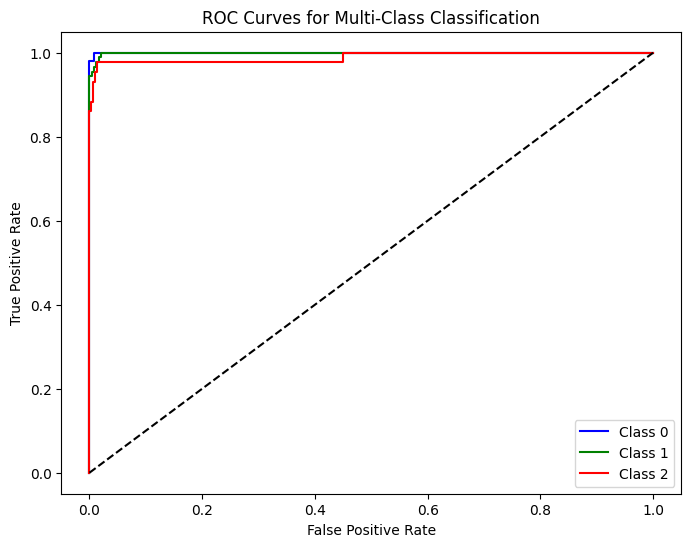

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from itertools import cycle

# Compute ROC-AUC Score
roc_auc = roc_auc_score(true_labels, probabilities, multi_class="ovr")
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Plot ROC Curves for each class
plt.figure(figsize=(8, 6))
colors = cycle(["b", "g", "r"])  # Colors for each class

for i, color in zip(range(probabilities.shape[1]), colors):
    fpr, tpr, _ = roc_curve(true_labels == i, probabilities[:, i])
    plt.plot(fpr, tpr, color=color, label=f"Class {i}")

plt.plot([0, 1], [0, 1], "k--")  # Random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Multi-Class Classification")
plt.legend()
plt.show()


In [44]:
#Adjusting the threshold for ROC-AUC

import numpy as np
from sklearn.metrics import precision_recall_fscore_support

def adjust_threshold(probabilities, true_labels, threshold=0.5):
    """
    Adjusts classification threshold and evaluates model performance.

    Parameters:
        probabilities (np.array): Model predicted probabilities of shape (num_samples, num_classes)
        true_labels (np.array): Ground truth labels of shape (num_samples,)
        threshold (float): Decision threshold (default = 0.5)

    Returns:
        precision, recall, f1_score for each class
    """
    adjusted_preds = np.argmax(probabilities > threshold, axis=1)  # Apply new threshold
    
    # Evaluate performance
    precision, recall, f1, _ = precision_recall_fscore_support(true_labels, adjusted_preds, average=None)

    return precision, recall, f1

# Example Usage: Set a new threshold (e.g., 0.6)
new_threshold = 0.6
precision, recall, f1 = adjust_threshold(probabilities, true_labels, threshold=new_threshold)

# Print the new performance metrics
print(f"Adjusted Threshold: {new_threshold}")
print(f"Precision per class: {precision}")
print(f"Recall per class: {recall}")
print(f"F1-score per class: {f1}")


Adjusted Threshold: 0.6
Precision per class: [0.98536585 0.98837209 0.93023256]
Recall per class: [1.         0.95505618 0.93023256]
F1-score per class: [0.99262899 0.97142857 0.93023256]


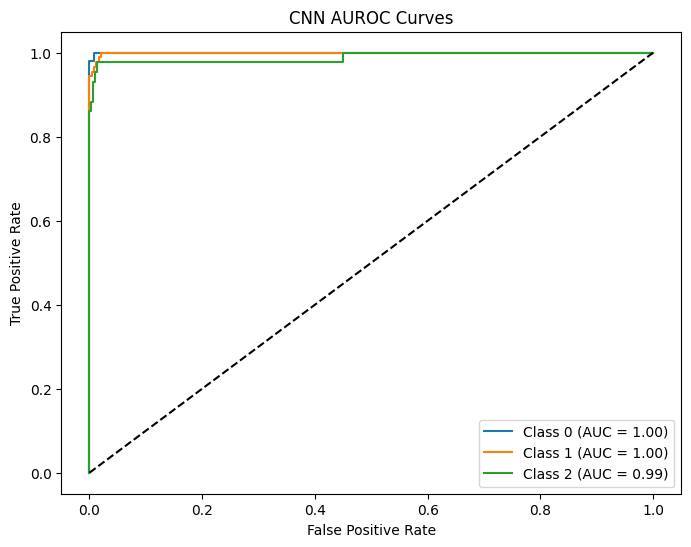

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Number of classes
num_classes = probabilities.shape[1]

plt.figure(figsize=(8, 6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(true_labels == i, probabilities[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")  # Random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CNN AUROC Curves")
plt.legend()
plt.show()


In [46]:
thresholds = np.linspace(0.1, 0.9, 9)  # Generate threshold values from 0.1 to 0.9
best_f1 = 0
best_threshold = 0

for t in thresholds:
    _, _, f1 = adjust_threshold(probabilities, true_labels, threshold=t)
    avg_f1 = np.mean(f1)  # Compute average F1-score across classes
    
    if avg_f1 > best_f1:
        best_f1 = avg_f1
        best_threshold = t

print(f"Best Threshold: {best_threshold}, Best F1-score: {best_f1:.4f}")


Best Threshold: 0.6, Best F1-score: 0.9648


In [47]:
# Lower threshold to favor recall
import numpy as np

# Set a lower threshold (e.g., 0.3 to prioritize recall)
new_threshold = 0.3  

# Convert softmax probabilities to class predictions
adjusted_predictions = (probabilities > new_threshold).astype(int)

print(f"Original Predictions: {np.argmax(probabilities, axis=1)}")
print(f"Adjusted Predictions (Threshold={new_threshold}):\n", adjusted_predictions)


Original Predictions: [1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2]
Adjusted Predictions (Threshold=0.3):
 [[0 1 0]
 [0 1 0]
 [1 0 0]
 ...
 [0 0 1]
 [0 0 1]
 [0 0 1]]


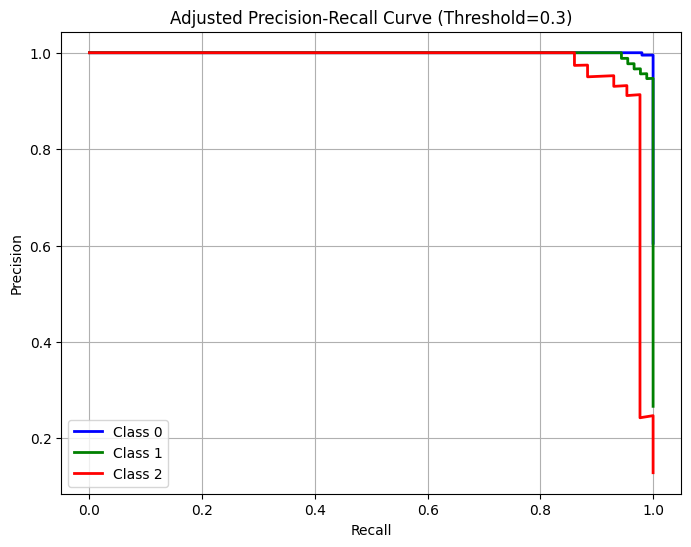

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from itertools import cycle

# Set a lower threshold to prioritize recall
new_threshold = 0.3  

# Convert softmax probabilities to adjusted class predictions
adjusted_predictions = (probabilities > new_threshold).astype(int)

# Precision-Recall curve for each class
plt.figure(figsize=(8, 6))
colors = cycle(["b", "g", "r"])

for i, color in zip(range(probabilities.shape[1]), colors):
    precision, recall, _ = precision_recall_curve(true_labels == i, probabilities[:, i])
    plt.plot(recall, precision, color=color, lw=2, label=f'Class {i}')

# Plot settings
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Adjusted Precision-Recall Curve (Threshold={new_threshold})")
plt.legend(loc="best")
plt.grid()
plt.show()


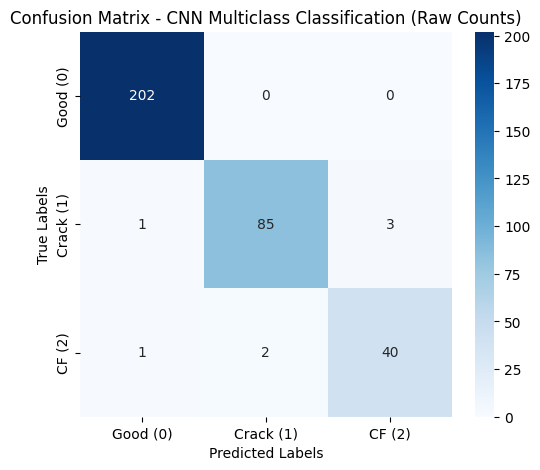

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Generate confusion matrix (raw counts)
conf_matrix = confusion_matrix(true_labels, pred_labels)

# Define class labels
class_names = ['Good (0)', 'Crack (1)', 'CF (2)']

# Plot confusion matrix with raw counts
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d",  # fmt="d" ensures integers
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - CNN Multiclass Classification (Raw Counts)")
plt.show()

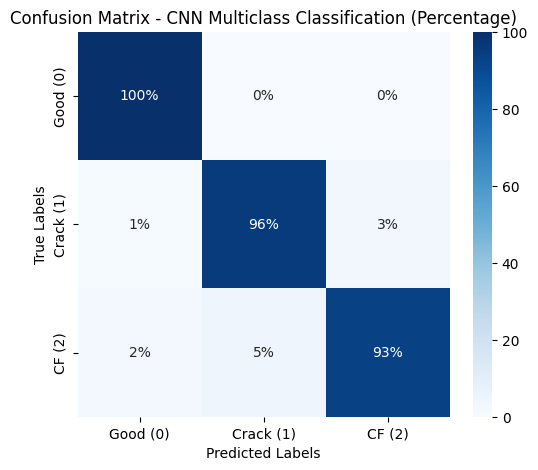

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Generate confusion matrix
conf_matrix = confusion_matrix(true_labels, pred_labels)

# Normalize confusion matrix (convert to percentages)
conf_matrix_norm = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

# Define class labels
class_names = ['Good (0)', 'Crack (1)', 'CF (2)']

# Format annotations with % sign
annotations = np.array([["{:.0f}%".format(value) for value in row] for row in conf_matrix_norm])

# Plot confusion matrix with percentage labels
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_norm, annot=annotations, cmap="Blues", fmt="",  # fmt="" to use custom annotations
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - CNN Multiclass Classification (Percentage)")
plt.show()